# 04 — Baseline Model Training (Composition-Only)

**Goal**: Train a gradient boosted tree on Tier 1 features, evaluate on OBELiX test set.

Benchmark: OBELiX paper reports MAE ~0.85 on their test set. If we beat that with just 
composition features, Tier 2 structural features are optimization. If we're at or above 0.85, 
structural features are essential.

**Prerequisites**: Run notebook 03 first.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

## Step 1: Load feature matrices

In [4]:
train = pd.read_csv('comp_train_features.csv')
test = pd.read_csv('comp_test_features.csv')

# Separate features and target
meta_cols = ['id', 'composition', 'log_conductivity']
feature_cols = [c for c in train.columns if c not in meta_cols]

# Drop any rows with NaN features
nan_mask = train[feature_cols].isna().any(axis=1)
print(f"Dropping {nan_mask.sum()} NaN rows from train")
train = train[~nan_mask]

nan_mask_test = test[feature_cols].isna().any(axis=1)
print(f"Dropping {nan_mask_test.sum()} NaN rows from test")
test = test[~nan_mask_test]

X_train = train[feature_cols].values
y_train = train['log_conductivity'].values
X_test = test[feature_cols].values
y_test = test['log_conductivity'].values

print(f"Training: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Test:     {X_test.shape[0]} samples, {X_test.shape[1]} features")
print(f"Features: {feature_cols}")

Dropping 3 NaN rows from train
Dropping 0 NaN rows from test
Training: 826 samples, 16 features
Test:     120 samples, 16 features
Features: ['li_count', 'mean_electronegativity', 'anion_electronegativity', 'cation_anion_en_diff', 'mean_ionic_radius', 'anion_ionic_radius', 'radius_std', 'anion_polarizability', 'mean_atomic_mass', 'n_elements', 'mean_atomic_number', 'anion_halide', 'anion_mixed', 'anion_other', 'anion_oxide', 'anion_sulfide']


## Step 2: Cross-validation on training set

Before touching the test set, check how the model performs via 5-fold CV on training data.
This tells us if we're overfitting or if the features have real signal.

In [5]:
model = GradientBoostingRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_leaf=5,
    random_state=42
)

# 5-fold cross-validation
cv_scores = cross_val_score(model, X_train, y_train, 
                            cv=5, scoring='neg_mean_absolute_error')
cv_mae = -cv_scores

print(f"5-fold CV MAE: {cv_mae.mean():.3f} ± {cv_mae.std():.3f}")
print(f"Per fold: {[f'{x:.3f}' for x in cv_mae]}")
print(f"\nOBELiX baseline MAE: ~0.85")
print(f"{'BEATING baseline' if cv_mae.mean() < 0.85 else 'Not yet beating baseline'} in CV")

5-fold CV MAE: 1.045 ± 0.371
Per fold: ['1.725', '0.712', '0.871', '0.771', '1.147']

OBELiX baseline MAE: ~0.85
Not yet beating baseline in CV


## Step 3: Train on full training set, evaluate on held-out test

This is the real number — same test set the OBELiX paper used.

In [6]:
# Train on all training data
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"={'='*45}")
print(f"  TEST SET RESULTS (composition-only model)")
print(f"={'='*45}")
print(f"  MAE:  {mae:.3f}  (baseline: ~0.85)")
print(f"  RMSE: {rmse:.3f}")
print(f"  R²:   {r2:.3f}")
print(f"{'='*45}")
if mae < 0.85:
    print(f"  Beating OBELiX baseline by {0.85 - mae:.3f}")
else:
    print(f"  {mae - 0.85:.3f} above baseline — structural features likely needed")

  TEST SET RESULTS (composition-only model)
  MAE:  1.144  (baseline: ~0.85)
  RMSE: 1.762
  R²:   0.521
  0.294 above baseline — structural features likely needed


## Step 4: Prediction vs actual plot

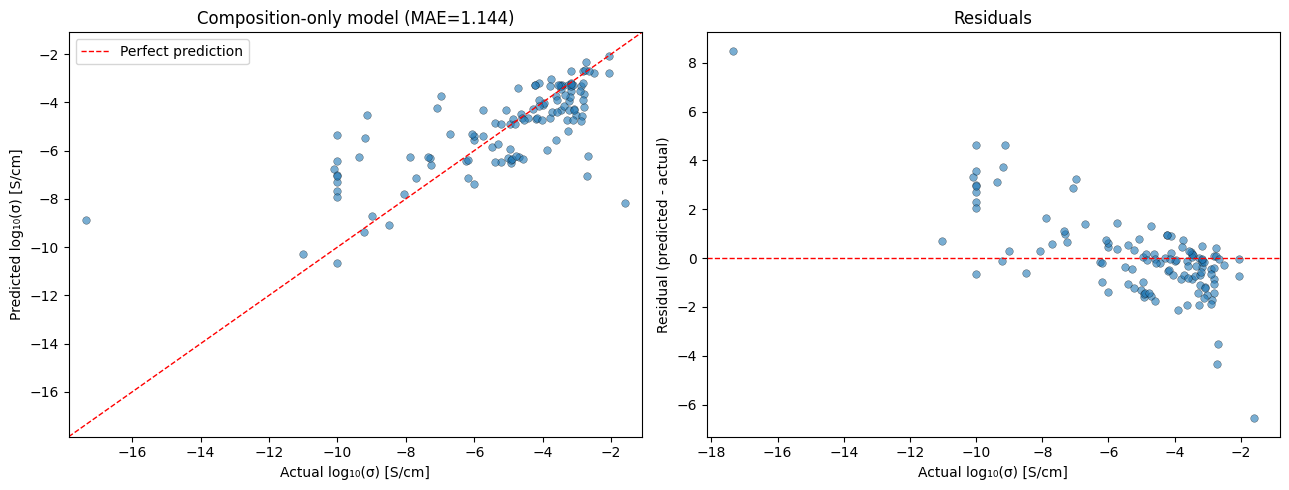


MAE by conductivity range:
  Low (< 10⁻⁸): MAE=2.619 (n=18)
  Mid (10⁻⁸ to 10⁻⁴): MAE=0.856 (n=49)
  High (> 10⁻⁴): MAE=0.908 (n=53)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Parity plot
ax = axes[0]
ax.scatter(y_test, y_pred, alpha=0.6, s=30, edgecolors='black', linewidths=0.3)
lims = [min(y_test.min(), y_pred.min()) - 0.5, max(y_test.max(), y_pred.max()) + 0.5]
ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
ax.set_xlabel('Actual log₁₀(σ) [S/cm]')
ax.set_ylabel('Predicted log₁₀(σ) [S/cm]')
ax.set_title(f'Composition-only model (MAE={mae:.3f})')
ax.legend()
ax.set_xlim(lims)
ax.set_ylim(lims)

# Residual plot
ax = axes[1]
residuals = y_pred - y_test
ax.scatter(y_test, residuals, alpha=0.6, s=30, edgecolors='black', linewidths=0.3)
ax.axhline(y=0, color='r', linestyle='--', linewidth=1)
ax.set_xlabel('Actual log₁₀(σ) [S/cm]')
ax.set_ylabel('Residual (predicted - actual)')
ax.set_title('Residuals')

plt.tight_layout()
plt.show()

# Check if errors are worse in any region
print("\nMAE by conductivity range:")
for lo, hi, label in [(-18, -8, "Low (< 10⁻⁸)"), (-8, -4, "Mid (10⁻⁸ to 10⁻⁴)"), (-4, 0, "High (> 10⁻⁴)")]:
    mask = (y_test >= lo) & (y_test < hi)
    if mask.sum() > 0:
        print(f"  {label}: MAE={mean_absolute_error(y_test[mask], y_pred[mask]):.3f} (n={mask.sum()})")

## Step 5: Feature importance

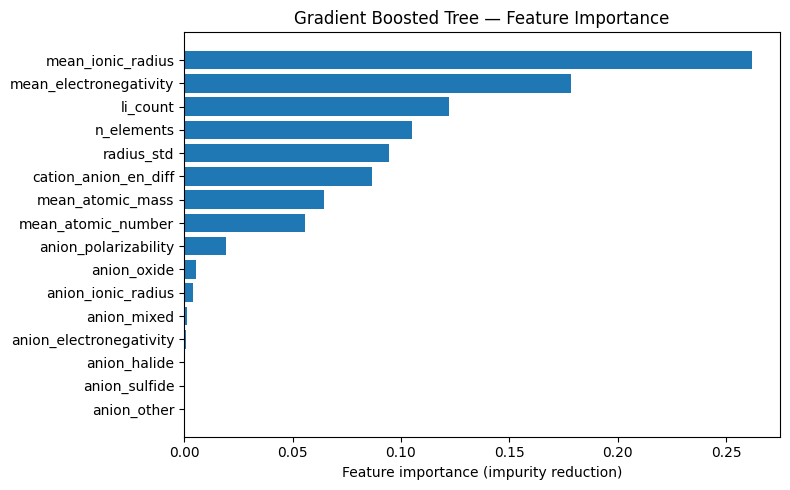


Top 5 features:
  mean_ionic_radius: 0.262
  mean_electronegativity: 0.179
  li_count: 0.122
  n_elements: 0.105
  radius_std: 0.094


In [8]:
importances = model.feature_importances_
sorted_idx = np.argsort(importances)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(range(len(sorted_idx)), importances[sorted_idx])
ax.set_yticks(range(len(sorted_idx)))
ax.set_yticklabels([feature_cols[i] for i in sorted_idx])
ax.set_xlabel('Feature importance (impurity reduction)')
ax.set_title('Gradient Boosted Tree — Feature Importance')
plt.tight_layout()
plt.show()

print("\nTop 5 features:")
for i in sorted_idx[-5:][::-1]:
    print(f"  {feature_cols[i]}: {importances[i]:.3f}")